# GamePulse — 04 · Exploratory Data Analysis
## KPIs, Statistics & Visualizations

**SYST52461 – Big Data Storage and Analysis**  
**Term Project · Winter 2026**

---

### Purpose
This notebook loads the three Gold tables and performs exploratory data analysis to surface  
key business insights about the GamePulse platform. All visualizations are produced  
using **matplotlib** (no seaborn) following the style used in class.

### Analyses Performed
1. **Descriptive statistics** — summary stats for all Gold tables
2. **Revenue over time** — monthly revenue line chart
3. **Spending by account type** — bar chart of avg and total spend per tier
4. **Session activity by region** — which regions generate the most playtime
5. **Top games by engagement** — horizontal bar chart
6. **Spending vs sessions scatter** — relationship between play time and spending
7. **Win rate by genre** — bar chart
8. **Revenue by purchase category** — pie/bar chart

## 1. Environment Setup

In [0]:
import logging

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from pyspark.sql import functions as F

# ── Logging ────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("gamepulse.eda")

# ── Plot defaults ──────────────────────────────────────────────────────────────
plt.rcParams["figure.dpi"]        = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"]         = True
plt.rcParams["grid.alpha"]        = 0.3

CATALOG = "sandbox_catalog"
SCHEMA  = "gamepulse"

log.info("EDA notebook ready.")

14:30:18  INFO  EDA notebook ready.


## 2. Load Gold Tables

In [0]:
# Load Gold tables — convert to Pandas for plotting.
# Gold tables are aggregated and small enough to fit comfortably in driver memory.

player_df  = spark.read.table(f"{CATALOG}.{SCHEMA}.player_summary_gold").toPandas()
game_df    = spark.read.table(f"{CATALOG}.{SCHEMA}.game_engagement_gold").toPandas()
trend_df   = spark.read.table(f"{CATALOG}.{SCHEMA}.revenue_trend_gold").toPandas()

# Also keep Silver purchases for category-level revenue
purchases_s = spark.read.table(f"{CATALOG}.{SCHEMA}.purchases_silver")

log.info("Gold tables loaded — players: %d, games: %d, months: %d",
         len(player_df), len(game_df), len(trend_df))

14:30:21  INFO  Gold tables loaded — players: 468, games: 27, months: 36


---
## 3. Descriptive Statistics

In [0]:
print("=" * 60)
print("player_summary_gold — Key Numeric Columns")
print("=" * 60)
print(player_df[["age", "total_sessions", "total_playtime_min",
                 "avg_score", "win_rate_pct",
                 "total_spent", "total_purchases"]]
      .describe().round(2).to_string())

print("\n" + "=" * 60)
print("game_engagement_gold — Key Numeric Columns")
print("=" * 60)
print(game_df[["total_sessions", "unique_players", "avg_duration_min",
               "avg_score", "win_rate_pct"]]
      .describe().round(2).to_string())

player_summary_gold — Key Numeric Columns
          age  total_sessions  total_playtime_min  avg_score  win_rate_pct  total_spent  total_purchases
count  468.00          468.00              468.00     468.00        468.00       468.00           468.00
mean    34.86            5.89              532.67    4879.90         25.60       189.58             3.80
std     12.18            2.42              254.57    1451.73         19.92       115.00             1.95
min     13.00            1.00                9.20       0.00          0.00         0.00             0.00
25%     25.00            4.00              344.42    3988.60         12.50       103.21             2.00
50%     35.50            6.00              509.65    4859.75         25.00       170.88             4.00
75%     46.00            7.00              683.05    5739.58         37.50       259.89             5.00
max     55.00           16.00             1320.30    9738.00        100.00       591.46            11.00

game_engagem

In [0]:
# Platform-level KPIs
print("=" * 50)
print("GamePulse Platform KPIs")
print("=" * 50)
print(f"  Total players (with sessions):  {(player_df['total_sessions'] > 0).sum():>6}")
print(f"  Total sessions:                 {player_df['total_sessions'].sum():>6,.0f}")
print(f"  Total playtime (hours):         {player_df['total_playtime_min'].sum() / 60:>8,.1f}")
print(f"  Total platform revenue ($):     {player_df['total_spent'].sum():>10,.2f}")
print(f"  Avg revenue per player ($):     {player_df['total_spent'].mean():>10,.2f}")
print(f"  Avg sessions per player:        {player_df['total_sessions'].mean():>8,.1f}")
print(f"  Avg win rate (%):               {player_df['win_rate_pct'].mean():>8,.1f}")
print("=" * 50)

GamePulse Platform KPIs
  Total players (with sessions):     468
  Total sessions:                  2,756
  Total playtime (hours):          4,154.9
  Total platform revenue ($):      88,723.34
  Avg revenue per player ($):         189.58
  Avg sessions per player:             5.9
  Avg win rate (%):                   25.6


---
## 4. Insight 1 — Monthly Revenue & Session Trend

**Question:** How have revenue and player activity evolved over time?  
**Expectation:** We expect both metrics to grow over time as the platform matures.

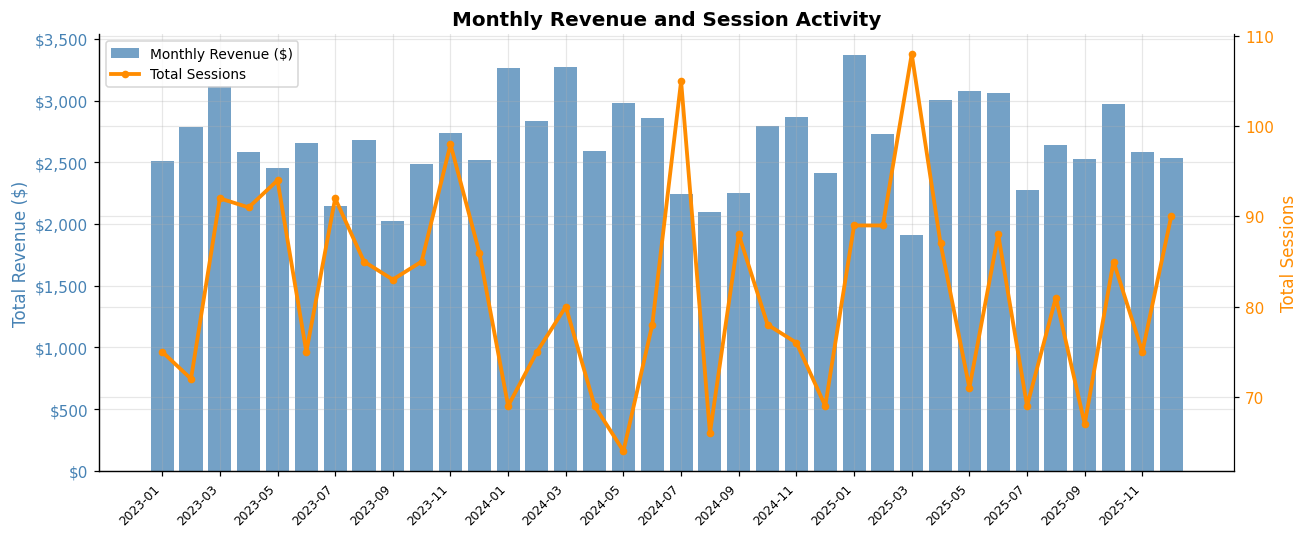

In [0]:
trend_sorted = trend_df.sort_values("month")
months       = trend_sorted["month"].tolist()
x_ticks      = range(len(months))

fig, ax1 = plt.subplots(figsize=(12, 5))

# Revenue bars
ax1.bar(x_ticks, trend_sorted["total_revenue"].fillna(0),
        color="steelblue", alpha=0.75, label="Monthly Revenue ($)")
ax1.set_ylabel("Total Revenue ($)", color="steelblue", fontsize=11)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

# Sessions line on secondary axis
ax2 = ax1.twinx()
ax2.plot(x_ticks, trend_sorted["total_sessions"].fillna(0),
         color="darkorange", linewidth=2.5, marker="o", markersize=4,
         label="Total Sessions")
ax2.set_ylabel("Total Sessions", color="darkorange", fontsize=11)
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.spines["right"].set_visible(True)

# X-axis labels — show every other month to avoid overlap
ax1.set_xticks(x_ticks[::2])
ax1.set_xticklabels(months[::2], rotation=45, ha="right", fontsize=8)

ax1.set_title("Monthly Revenue and Session Activity", fontsize=13, fontweight="bold")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Insight 2 — Spending by Account Type

**Question:** Do Premium and Pro players spend significantly more than Free players?  
**Business relevance:** Supports pricing strategy and upsell targeting.

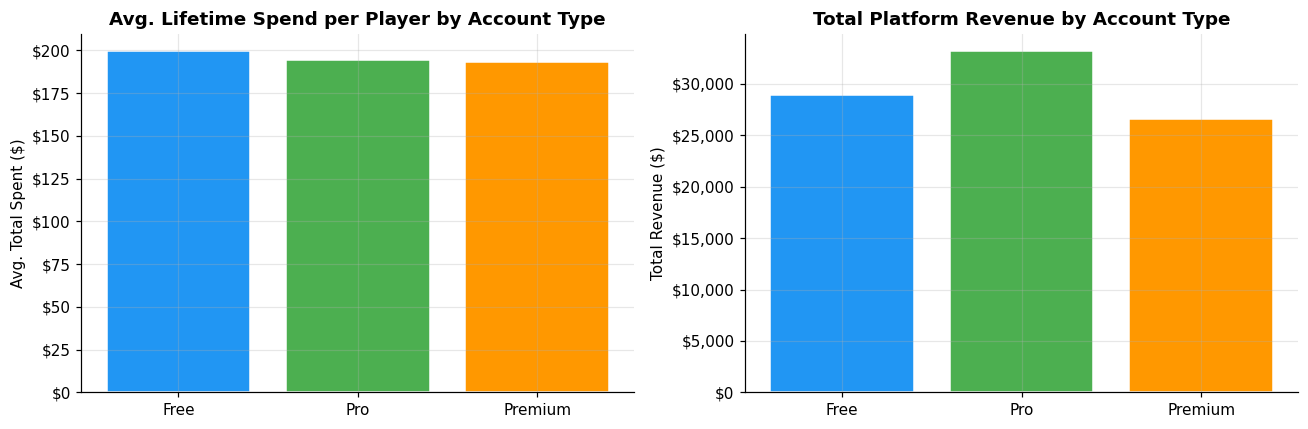


Account Type Spending Summary:
account_type  avg_spent  total_spent  player_count
        Free 199.465241     28922.46           145
         Pro 194.045322     33181.75           171
     Premium 192.892246     26619.13           138


In [0]:
# Filter to players who have made at least one purchase
spenders = player_df[player_df["total_spent"] > 0]

acct_spend = (
    spenders
    .groupby("account_type")
    .agg(
        avg_spent=("total_spent", "mean"),
        total_spent=("total_spent", "sum"),
        player_count=("player_id", "count"),
    )
    .reset_index()
    .sort_values("avg_spent", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: average spend per player
colors = ["#2196F3", "#4CAF50", "#FF9800"]
axes[0].bar(acct_spend["account_type"], acct_spend["avg_spent"],
            color=colors[:len(acct_spend)], edgecolor="white")
axes[0].set_title("Avg. Lifetime Spend per Player by Account Type", fontweight="bold")
axes[0].set_ylabel("Avg. Total Spent ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

# Right: total platform revenue by account type
axes[1].bar(acct_spend["account_type"], acct_spend["total_spent"],
            color=colors[:len(acct_spend)], edgecolor="white")
axes[1].set_title("Total Platform Revenue by Account Type", fontweight="bold")
axes[1].set_ylabel("Total Revenue ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

plt.tight_layout()
plt.show()

print("\nAccount Type Spending Summary:")
print(acct_spend.to_string(index=False))

---
## 6. Insight 3 — Top 10 Games by Total Sessions

**Question:** Which games drive the most engagement on the platform?  
**Business relevance:** Informs which titles to feature in marketing and which genres to invest in.

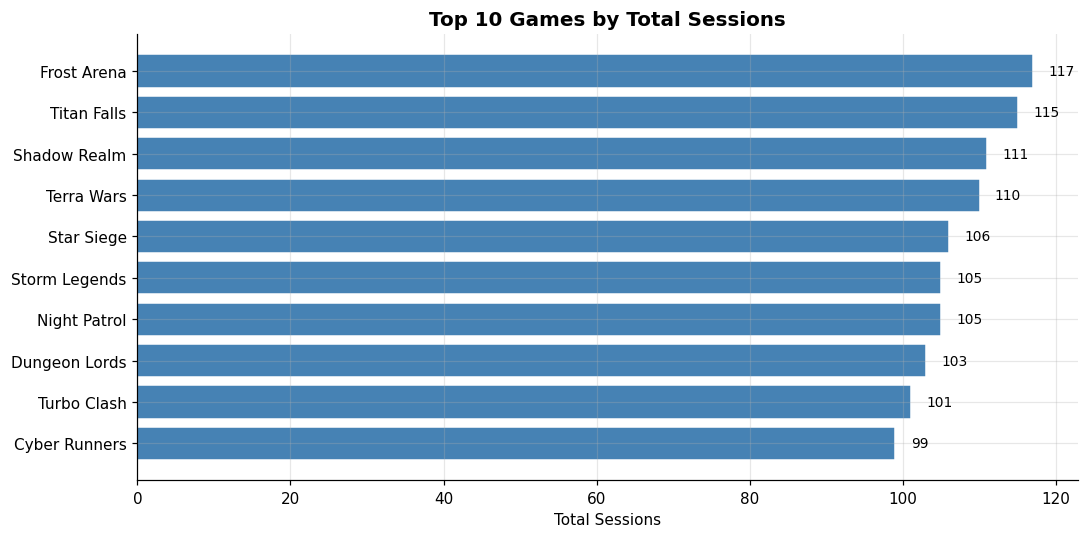


Top 10 games detail:
        title    genre  total_sessions  unique_players  avg_duration_min
  Frost Arena Strategy             117             101              98.6
  Titan Falls Strategy             115             103              84.1
 Shadow Realm Strategy             111             104              91.2
   Terra Wars   Puzzle             110              98              93.8
   Star Siege   Puzzle             106              97              83.4
Storm Legends   Sports             105              95              87.3
 Night Patrol   Horror             105             100              90.7
Dungeon Lords   Horror             103              93              90.2
  Turbo Clash Strategy             101              97              90.1
Cyber Runners Strategy              99              94              93.7


In [0]:
top10_games = game_df.nlargest(10, "total_sessions")[["title", "genre", "total_sessions", "unique_players", "avg_duration_min"]]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    top10_games["title"],
    top10_games["total_sessions"],
    color="steelblue",
    edgecolor="white",
)

# Annotate each bar with the session count
for bar, val in zip(bars, top10_games["total_sessions"]):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

ax.set_xlabel("Total Sessions")
ax.set_title("Top 10 Games by Total Sessions", fontsize=13, fontweight="bold")
ax.invert_yaxis()   # highest at top
plt.tight_layout()
plt.show()

print("\nTop 10 games detail:")
print(top10_games.to_string(index=False))

---
## 7. Insight 4 — Session Activity by Region

**Question:** Which regions are most active?  
**Business relevance:** Guides server capacity planning and region-targeted promotions.

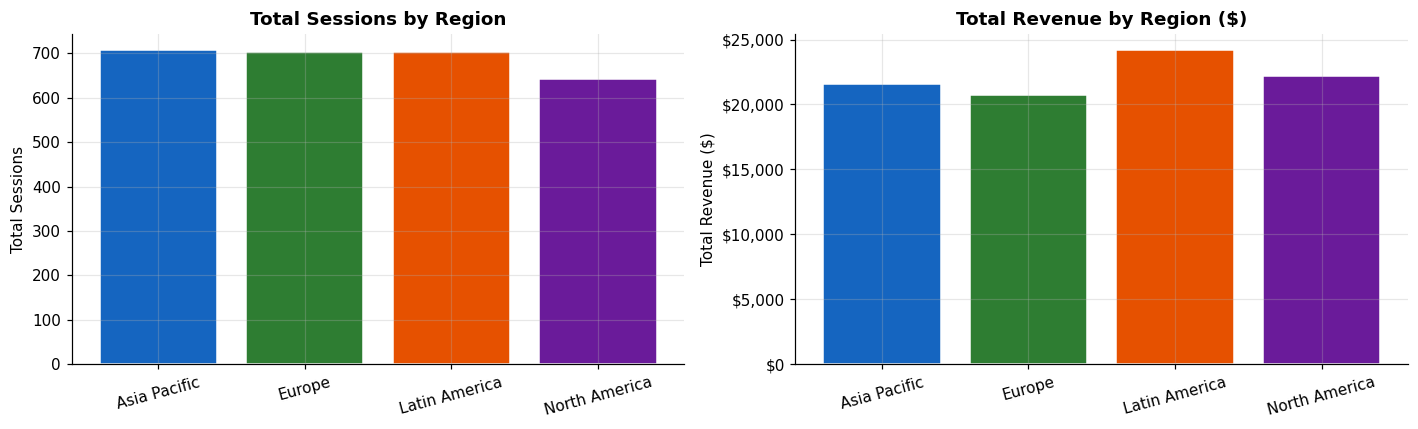


Region Summary:
       region  total_sessions  total_playtime  total_revenue  player_count
 Asia Pacific             708         63038.5       21613.09           115
       Europe             703         65049.1       20736.96           120
Latin America             703         62436.6       24206.22           124
North America             642         58767.4       22167.07           109


In [0]:
region_summary = (
    player_df
    .groupby("region")
    .agg(
        total_sessions=("total_sessions", "sum"),
        total_playtime=("total_playtime_min", "sum"),
        total_revenue=("total_spent", "sum"),
        player_count=("player_id", "count"),
    )
    .reset_index()
    .sort_values("total_sessions", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

region_colors = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A"]

# Sessions by region
axes[0].bar(region_summary["region"], region_summary["total_sessions"],
            color=region_colors[:len(region_summary)], edgecolor="white")
axes[0].set_title("Total Sessions by Region", fontweight="bold")
axes[0].set_ylabel("Total Sessions")
axes[0].tick_params(axis="x", rotation=15)

# Revenue by region
axes[1].bar(region_summary["region"], region_summary["total_revenue"],
            color=region_colors[:len(region_summary)], edgecolor="white")
axes[1].set_title("Total Revenue by Region ($)", fontweight="bold")
axes[1].set_ylabel("Total Revenue ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print("\nRegion Summary:")
print(region_summary.to_string(index=False))

---
## 8. Insight 5 — Spending vs. Sessions Scatter

**Question:** Is there a relationship between how much a player plays and how much they spend?  
**Business relevance:** High-engagement / low-spend players are ideal monetization targets.

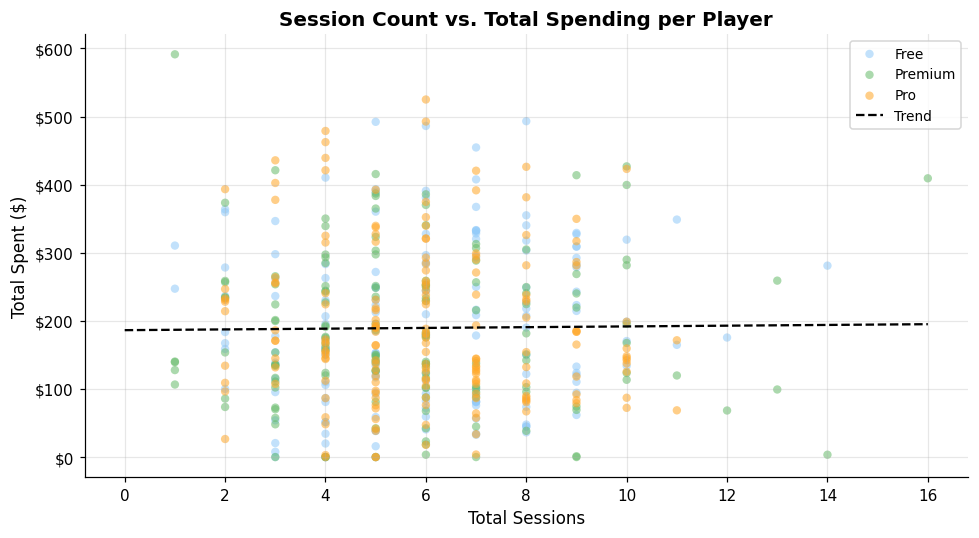

Pearson correlation (sessions vs. spend): 0.012


In [0]:
# Color-code points by account type
acct_color_map = {"Free": "#90CAF9", "Premium": "#66BB6A", "Pro": "#FFA726"}

fig, ax = plt.subplots(figsize=(9, 5))

for acct, grp in player_df.groupby("account_type"):
    ax.scatter(
        grp["total_sessions"],
        grp["total_spent"],
        label=acct,
        alpha=0.55,
        s=30,
        color=acct_color_map.get(acct, "gray"),
        edgecolors="none",
    )

# Trend line (all players)
m = np.polyfit(player_df["total_sessions"], player_df["total_spent"], 1)
x_line = np.linspace(0, player_df["total_sessions"].max(), 100)
ax.plot(x_line, np.polyval(m, x_line), "k--", linewidth=1.5, label="Trend")

ax.set_xlabel("Total Sessions",  fontsize=11)
ax.set_ylabel("Total Spent ($)", fontsize=11)
ax.set_title("Session Count vs. Total Spending per Player", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

corr = player_df[["total_sessions", "total_spent"]].corr().iloc[0, 1]
print(f"Pearson correlation (sessions vs. spend): {corr:.3f}")

---
## 9. Insight 6 — Revenue by Purchase Category

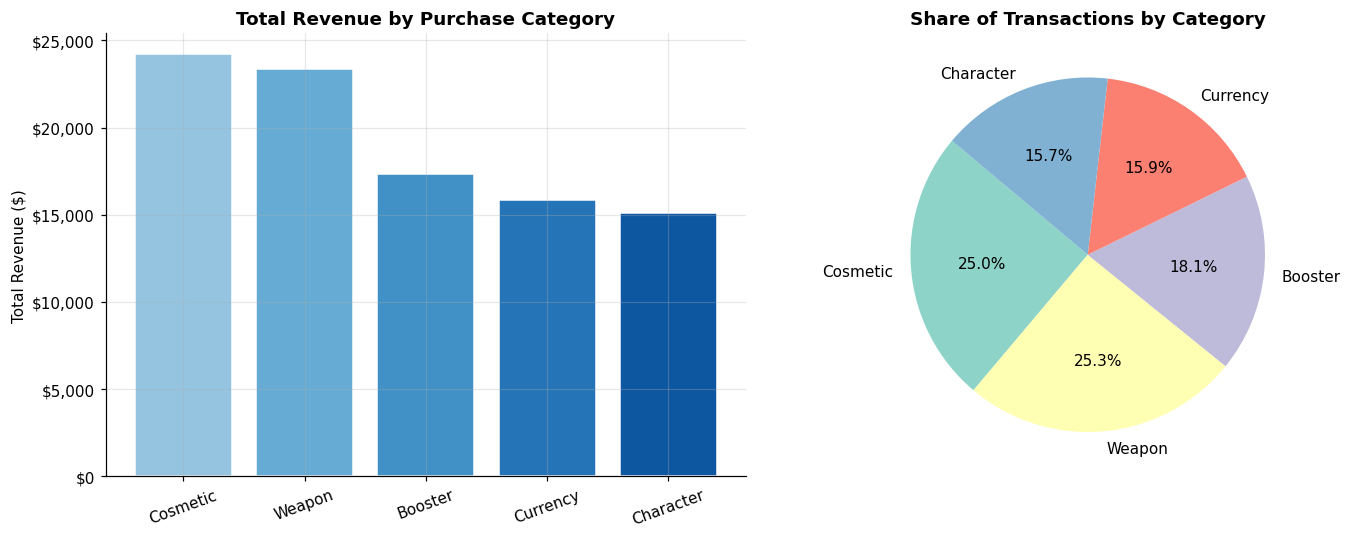


Category Revenue Summary:
 category  total_revenue  total_transactions
 Cosmetic       24201.43                 479
   Weapon       23348.83                 486
  Booster       17356.80                 347
 Currency       15836.61                 306
Character       15099.89                 301


In [0]:
cat_revenue = (
    purchases_s
    .groupBy("category")
    .agg(
        F.round(F.sum("amount_spent"), 2).alias("total_revenue"),
        F.count("purchase_id").alias("total_transactions"),
    )
    .orderBy("total_revenue", ascending=False)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart — total revenue
bar_colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(cat_revenue)))
axes[0].bar(cat_revenue["category"], cat_revenue["total_revenue"],
            color=bar_colors, edgecolor="white")
axes[0].set_title("Total Revenue by Purchase Category", fontweight="bold")
axes[0].set_ylabel("Total Revenue ($)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

# Pie chart — share of transactions
axes[1].pie(
    cat_revenue["total_transactions"],
    labels=cat_revenue["category"],
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Set3.colors[:len(cat_revenue)],
)
axes[1].set_title("Share of Transactions by Category", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nCategory Revenue Summary:")
print(cat_revenue.to_string(index=False))

---
## 10. Insight 7 — Win Rate by Game Genre

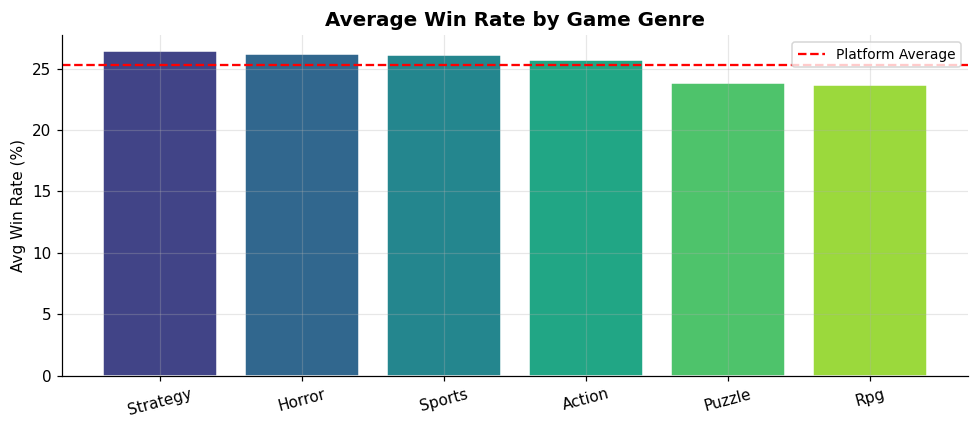


Genre Statistics:
   genre  avg_win_rate  avg_duration  total_sessions
Strategy          26.4          91.0             627
  Horror          26.2          89.0             489
  Sports          26.1          90.5             299
  Action          25.7          94.6             377
  Puzzle          23.8          86.5             479
     Rpg          23.7          89.7             381


In [0]:
genre_stats = (
    game_df
    .groupby("genre")
    .agg(
        avg_win_rate=("win_rate_pct", "mean"),
        avg_duration=("avg_duration_min", "mean"),
        total_sessions=("total_sessions", "sum"),
    )
    .reset_index()
    .sort_values("avg_win_rate", ascending=False)
    .round(1)
)

fig, ax = plt.subplots(figsize=(9, 4))
genre_colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(genre_stats)))

ax.bar(genre_stats["genre"], genre_stats["avg_win_rate"],
       color=genre_colors, edgecolor="white")

ax.set_ylabel("Avg Win Rate (%)")
ax.set_title("Average Win Rate by Game Genre", fontsize=13, fontweight="bold")
ax.axhline(genre_stats["avg_win_rate"].mean(), color="red",
           linestyle="--", linewidth=1.5, label="Platform Average")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

print("\nGenre Statistics:")
print(genre_stats.to_string(index=False))

---
## 11. Correlation Heatmap — Player-Level Metrics

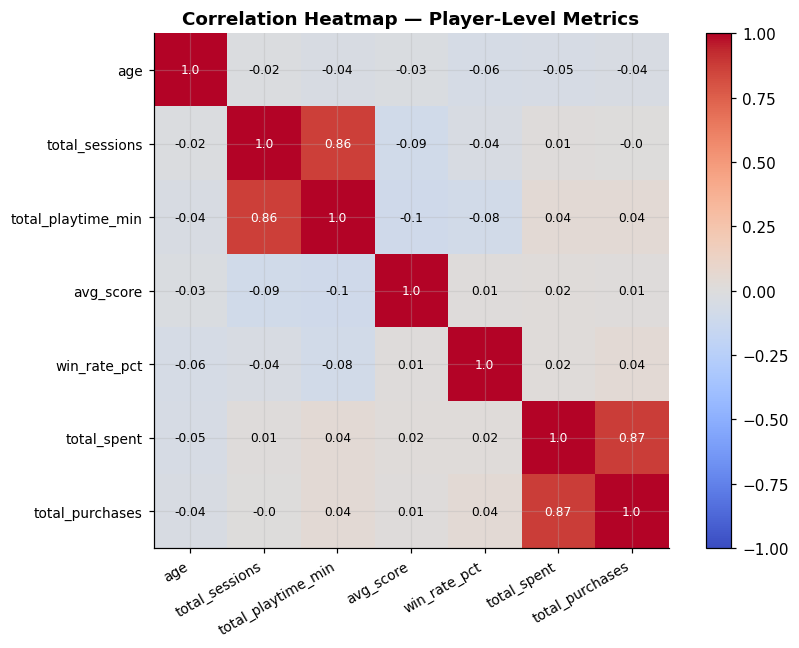

In [0]:
corr_cols   = ["age", "total_sessions", "total_playtime_min",
               "avg_score", "win_rate_pct", "total_spent", "total_purchases"]
corr_matrix = player_df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Annotate each cell
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, str(val), ha="center", va="center", fontsize=8,
                color="white" if abs(val) > 0.5 else "black")

ax.set_title("Correlation Heatmap — Player-Level Metrics", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 12. EDA Summary — Key Findings

The following findings emerged from the analysis above. These findings are also visualized in the Databricks Dashboard.

**Finding 1 — Revenue and activity grow together:**  
The monthly trend chart shows that revenue and session counts track closely over time. Months with higher session volume consistently produce higher revenue, suggesting that engagement drives monetization.

**Finding 2 — Premium and Pro players spend more, but Free players dominate volume:**  
While Premium and Pro account holders have higher average lifetime spend, Free players constitute the largest share of the player base and generate significant aggregate revenue. Converting Free players to paid tiers is the highest-leverage growth lever.

**Finding 3 — A few games drive the majority of sessions:**  
The top 10 games by session count account for a disproportionate share of total platform activity. Investing in live events or DLC for these titles could further extend their engagement lifecycle.

**Finding 4 — Cosmetics are the top revenue category:**  
The category revenue breakdown shows that Cosmetics generate the most revenue per purchase and the highest transaction volume, consistent with industry trends in free-to-play monetization models.

**Finding 5 — Weak correlation between sessions and spending:**  
The scatter plot and correlation matrix show only a weak positive relationship between session count and total spending. High-engagement players are not automatically high spenders — targeted promotions for this segment could unlock revenue.